# **Latin Part Of Speech Tagging**

Using individual Latin words dataset.

## **Set Up Environment**

In [ ]:
import os

### Installing Latin BERT

In [ ]:
# clone latin bert repo
!git clone https://github.com/dbamman/latin-bert.git
%cd latin-bert

fatal: destination path 'latin-bert' already exists and is not an empty directory.
/content/latin-bert


In [ ]:
# Download pre-trained BERT model for Latin
!./scripts/download.sh

--2026-03-11 18:55:17--  https://drive.usercontent.google.com/download?export=download&id=1Te_14UB-DZ8wYPhHGyDg7LadDTjNzpti&confirm=t&uuid=a94428cb-ac46-4971-bae7-4b4375602a1b
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.12.132, 2404:6800:4003:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.12.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448020480 (427M) [application/octet-stream]
Saving to: ‘latin_bert.tar’

latin_bert.tar      100%[===================>] 427.27M  51.1MB/s    in 8.6s    

2026-03-11 18:55:27 (49.7 MB/s) - ‘latin_bert.tar’ saved [448020480/448020480]



In [ ]:
!ls -lah models/latin_bert | head

total 428M
drwxrwxr-x 2 1001 1001 4.0K Sep  4  2020 .
drwxr-xr-x 4 root root 4.0K Mar 11 18:55 ..
-rw-rw-r-- 1 1001 1001  503 Sep  4  2020 config.json
-rw-rw-r-- 1 1001 1001 428M Sep  4  2020 pytorch_model.bin
-rw-rw-r-- 1 1001 1001 217K Sep  4  2020 vocab.txt


In [ ]:
%cd ..

/content


In [ ]:
MODEL_PATH = os.path.join("latin-bert", "models", "latin_bert")

### Import Dependencies

In [ ]:
import random
from typing import Dict, List
import numpy as np
import pandas as pd
import torch
import transformers
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer, set_seed
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
print(torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

True
Using device: cuda


## **Prepare Data**

### Load Dataset

In [ ]:
DATA_PATH = '/content/drive/MyDrive/FYP/words_data.csv'

In [ ]:
df = pd.read_csv(DATA_PATH, dtype=str)

In [ ]:
# Basic cleanup
df = df.dropna(subset=["form", "part_of_speech"]).copy()
df["form"] = df["form"].astype(str).str.strip()
df["part_of_speech"] = df["part_of_speech"].astype(str).str.strip()

In [ ]:
df.head()

,lemma,form,features,part_of_speech,gender,case,number,tense,voice,mood,person,aspect,finiteness,lang_specific,conjugation,declension,degree,participle_type,comment
0,verēdārius,verēdārius,N;NOM;SG,N,MASC,NOM,SG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
1,verēdārius,verēdāriī,N;NOM;PL,N,MASC,NOM,PL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
2,verēdārius,verēdāriī,N;GEN;SG,N,NEUT,GEN,SG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
3,verēdārius,verēdārī,N;GEN;SG,N,NaN,GEN,SG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,verēdārius,verēdāriōrum,N;GEN;PL,N,NEUT,GEN,PL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN


In [ ]:
# dataset summary
print(f"Dataset size: {len(df)} rows")
print(f"Categories: {df['part_of_speech'].value_counts().to_dict()}")

Dataset size: 976489 rows
Intents: {'V.PTCP': 462668, 'ADJ': 244197, 'N': 163182, 'PROPN': 51846, 'V': 46790, 'V+V.MSDR': 4886, 'V+V.PTCP': 2920}


### Split into Train/Test/Validation Sets

In [ ]:
# 70% train, 15% test, 15% val
train_df, test_val_df = train_test_split(df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=0.5, random_state=42)

In [ ]:
print(len(train_df), "train samples")
print(len(test_df), "test samples")
print(len(val_df), "validation samples")

683542 train samples
146473 test samples
146474 validation samples


### Data Preprocessing

In [ ]:
# Build label maps
labels_sorted = sorted(df["part_of_speech"].unique().tolist())
label2id: Dict[str, int] = {lab: i for i, lab in enumerate(labels_sorted)}
id2label: Dict[int, str] = {i: lab for lab, i in label2id.items()}

print(label2id)
print(id2label)

{'ADJ': 0, 'N': 1, 'PROPN': 2, 'V': 3, 'V+V.MSDR': 4, 'V+V.PTCP': 5, 'V.PTCP': 6}
{0: 'ADJ', 1: 'N', 2: 'PROPN', 3: 'V', 4: 'V+V.MSDR', 5: 'V+V.PTCP', 6: 'V.PTCP'}


In [ ]:
train_df['label'] = train_df['part_of_speech'].map(label2id)
val_df['label']   = val_df['part_of_speech'].map(label2id)
test_df['label']  = test_df['part_of_speech'].map(label2id)

train_df.head()

,lemma,form,features,part_of_speech,gender,case,number,tense,voice,mood,person,aspect,finiteness,lang_specific,conjugation,declension,degree,participle_type,comment,label
864205,expoliandus,expoliandō,V.PTCP;DAT;NEUT;SG,V.PTCP,NEUT,DAT,SG,FUT,PASS,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,PPL,NaN,6
602001,bifer,biferum,ADJ;ACC;NEUT;SG,ADJ,NEUT,ACC,SG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,POS,NaN,NaN,0
792088,praeōrdinandus,praeōrdinanda,V.PTCP;NOM;FEM;SG,V.PTCP,FEM,NOM,SG,FUT,PASS,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,PPL,NaN,6
894190,convīciātus,convīciāta,V.PTCP;ACC;NEUT;PL,V.PTCP,NEUT,ACC,PL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
889474,placidus,placida,ADJ;NOM;NEUT;PL,ADJ,NEUT,NOM,PL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,POS,NaN,NaN,0


## **Tokenizer**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [ ]:
type(tokenizer)

transformers.models.bert.tokenization_bert.BertTokenizer

In [ ]:
# tokenize function
def tokenize(batch):
    return tokenizer(
        batch["form"],
        truncation=True,
        padding="max_length",
        max_length=16
    )

### Tokenize Dataset

In [ ]:
# convert dataframes to type Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
# tokenize the dataset
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/683542 [00:00<?, ? examples/s]

Map:   0%|          | 0/146474 [00:00<?, ? examples/s]

Map:   0%|          | 0/146473 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0])

{'lemma': 'expoliandus', 'form': 'expoliandō', 'features': 'V.PTCP;DAT;NEUT;SG', 'part_of_speech': 'V.PTCP', 'gender': 'NEUT', 'case': 'DAT', 'number': 'SG', 'tense': 'FUT', 'voice': 'PASS', 'mood': None, 'person': None, 'aspect': None, 'finiteness': None, 'lang_specific': None, 'conjugation': '1', 'declension': None, 'degree': None, 'participle_type': 'PPL', 'comment': None, 'label': 6, '__index_level_0__': 864205, 'input_ids': [2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


## **Model**

### Load Model

In [ ]:
# class MorphologicalAnalyser(torch.nn.Module):
#   def __init__(self):
#     pass

#   def forward(self):
#     pass

#   def evaluate(self):
#     pass

#   def predict(self):
#     pass

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: latin-bert/models/latin_bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly 

In [ ]:
type(model)

transformers.models.bert.modeling_bert.BertForSequenceClassification

In [ ]:
training_args = TrainingArguments(
    # output_dir="/content/drive/MyDrive/FYP/pos_form_classifier",  # Directory to save model checkpoints
    output_dir="amysp/latin-morphological-analyser",              # huggingface repo
    push_to_hub=True,                                             # enables auto-upload to hub
    hub_strategy="every_save",                                    # uploads to repo each time a checkpoint is saved
    hub_private_repo=True,                                        # keeps the repo private
    eval_strategy="epoch",                                        # Evaluate on validation set every epoch
    save_strategy="epoch",                                        # Save model checkpoints every epoch
    learning_rate=5e-5,                                           # Learning rate
    warmup_steps=0.1,                                             # Proportion of training steps to linearly increase learning rate
    per_device_train_batch_size=32,                               # Batch size for training
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    num_train_epochs=100,                                          # Number of training epochs
    weight_decay=0.01,                                            # Regularization to prevent overfitting
    # logging_steps=50,
    load_best_model_at_end=True,                                  # Load the best model based on evaluation metrics
    save_total_limit=1,                                           # Max number of checkpoints to keep - keeps best and most recent
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    fp16=True                                                     # Enable mixed precision for faster training
)

### Training

In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = logits.argmax(axis=1)
  return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[transformers.EarlyStoppingCallback(early_stopping_patience=10)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.334632,1.339831,0.478174
2,1.349049,1.335655,0.478720
3,1.336445,1.335402,0.478617
4,1.336699,1.336638,0.478119
5,1.350440,1.347936,0.472439
6,1.352299,1.347691,0.472439
7,1.349514,1.347091,0.472439
8,1.337104,1.346037,0.472439
9,1.348144,1.347977,0.472439
10,1.337561,1.346212,0.472439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=256332, training_loss=1.3451836370821704, metrics={'train_runtime': 20841.2342, 'train_samples_per_second': 3279.758, 'train_steps_per_second': 102.494, 'total_flos': 6.74458240843584e+16, 'train_loss': 1.3451836370821704, 'epoch': 12.0})

### Plot Training vs Validation Loss Curve

In [ ]:
trainer.state.log_history

[{'loss': 1.9104903564453124,
  'grad_norm': 6.754801273345947,
  'learning_rate': 1.1680164786292778e-07,
  'epoch': 0.023407143860306165,
  'step': 500},
 {'loss': 1.5640771484375,
  'grad_norm': 7.3357672691345215,
  'learning_rate': 2.3383736716445858e-07,
  'epoch': 0.04681428772061233,
  'step': 1000},
 {'loss': 1.41176123046875,
  'grad_norm': 7.58266019821167,
  'learning_rate': 3.5087308646598945e-07,
  'epoch': 0.0702214315809185,
  'step': 1500},
 {'loss': 1.378302734375,
  'grad_norm': 5.187004089355469,
  'learning_rate': 4.679088057675203e-07,
  'epoch': 0.09362857544122466,
  'step': 2000},
 {'loss': 1.355442138671875,
  'grad_norm': 4.814538955688477,
  'learning_rate': 5.849445250690511e-07,
  'epoch': 0.11703571930153082,
  'step': 2500},
 {'loss': 1.3588848876953126,
  'grad_norm': 4.9006123542785645,
  'learning_rate': 7.019802443705819e-07,
  'epoch': 0.140442863161837,
  'step': 3000},
 {'loss': 1.355847900390625,
  'grad_norm': 3.787191867828369,
  'learning_rate

In [ ]:
# get training log history
log_history = trainer.state.log_history

train_epochs = []
train_loss = []

val_epochs = []
val_loss = []

for entry in log_history:
    # training loss
    if "loss" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # validation loss
    if "eval_loss" in entry:
        val_epochs.append(entry["epoch"])
        val_loss.append(entry["eval_loss"])

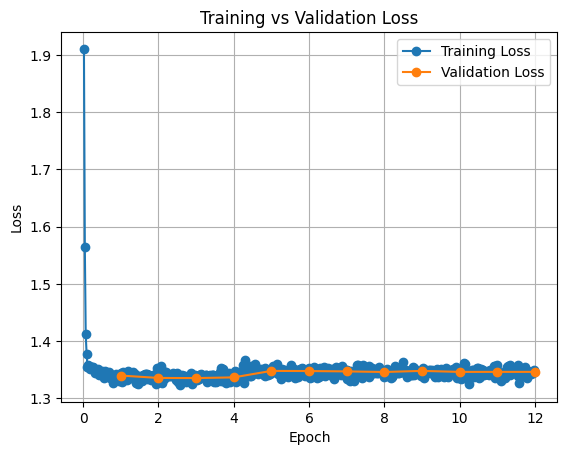

In [ ]:
# plot training vs val loss
plt.figure()

plt.plot(train_epochs, train_loss, marker='o', label="Training Loss")
plt.plot(val_epochs, val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Evaluate Finetuned Model

In [ ]:
# evaluate finetuned model
results = trainer.evaluate()
results

{'eval_loss': 1.4261292219161987,
 'eval_accuracy': 0.4786310198396985,
 'eval_runtime': 74.4502,
 'eval_samples_per_second': 1967.409,
 'eval_steps_per_second': 61.491,
 'epoch': 12.0}

### Save Model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser")
tokenizer.save_pretrained("/content/drive/MyDrive/FYP/morphological_analyser")

trainer.push_to_hub()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nalyser/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...nalyser/model.safetensors:   7%|7         | 31.9MB /  445MB            

CommitInfo(commit_url='https://huggingface.co/amysp/latin-morphological-analyser/commit/d74a0d1933fee0e004c3703905f7534afc06fa45', commit_message='End of training', commit_description='', oid='d74a0d1933fee0e004c3703905f7534afc06fa45', pr_url=None, repo_url=RepoUrl('https://huggingface.co/amysp/latin-morphological-analyser', endpoint='https://huggingface.co', repo_type='model', repo_id='amysp/latin-morphological-analyser'), pr_revision=None, pr_num=None)

## **Evaluation**

In [ ]:
# load final model and tokenizer
MODEL_PATH = "/content/drive/MyDrive/FYP/morphological_analyser"

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# evaluate model on test set
trainer.evaluate(test_dataset)

{'eval_loss': 1.427257776260376,
 'eval_model_preparation_time': 0.0046,
 'eval_accuracy': 0.4795081687409966,
 'eval_runtime': 229.3872,
 'eval_samples_per_second': 638.54,
 'eval_steps_per_second': 79.821}

### Confusion Matrix

In [ ]:
# get predictions on test set
pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)
labels = pred_output.label_ids

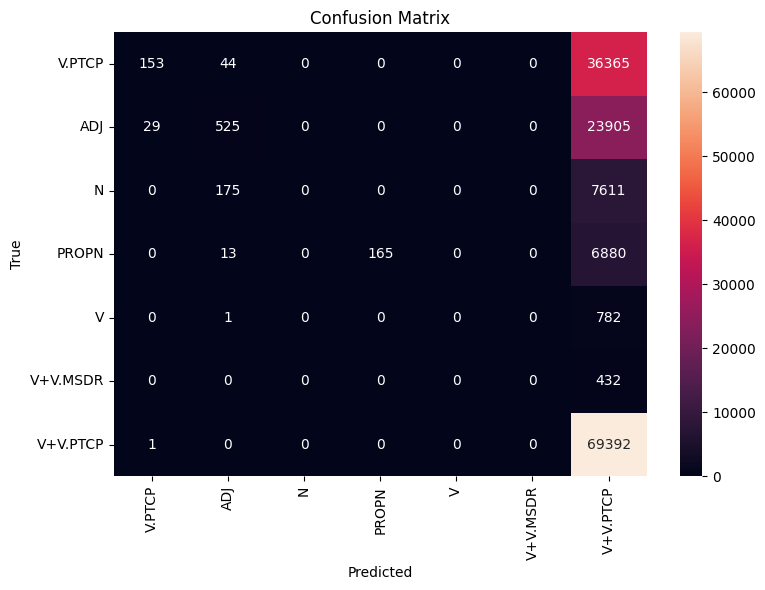

In [ ]:
# plot confusion matrix

# create confusion matrix
cm = confusion_matrix(labels, preds)

pos_counts = df['part_of_speech'].value_counts()
label_names = pos_counts.index

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
# plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

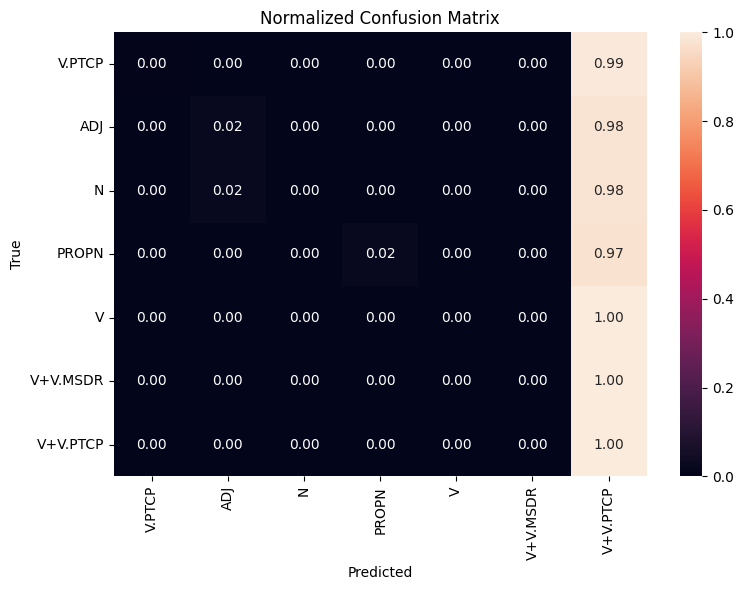

In [ ]:
# normalised confusion matrix
cm_norm = confusion_matrix(labels, preds, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.yticks(rotation=0)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

### Classification Report

In [ ]:
# classification report
print(classification_report(labels, preds, target_names=label_names))

              precision    recall  f1-score   support

      V.PTCP       0.84      0.00      0.01     36562
         ADJ       0.69      0.02      0.04     24459
           N       0.00      0.00      0.00      7786
       PROPN       1.00      0.02      0.05      7058
           V       0.00      0.00      0.00       783
    V+V.MSDR       0.00      0.00      0.00       432
    V+V.PTCP       0.48      1.00      0.65     69393

    accuracy                           0.48    146473
   macro avg       0.43      0.15      0.11    146473
weighted avg       0.60      0.48      0.32    146473



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
